In [139]:
import sys
!{sys.executable} -m pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Exploratory Data Analysis: Include a small number of relevant summaries or plots and focus on insights that influenced your modeling.

In [140]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

In [141]:
# Data loading

train = pd.read_csv("C:/Users/2003n/Downloads/midterm_train.csv")
test = pd.read_csv("C:/Users/2003n/Downloads/midterm_test.csv")

In [142]:
train.head()

,id,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,...,prior_contact_count,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,accepted_offer,is_repeat_customer,recent_contact_flag
0,12556,28,services,married,high.school,no,yes,no,jul,tue,...,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,0,0
1,35451,27,admin.,married,university.degree,no,yes,yes,jul,fri,...,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,0,0,0
2,30592,43,self-employed,married,high.school,unknown,yes,no,apr,wed,...,0,nonexistent,-1.8,93.075,-47.1,1.498,5099.1,0,0,0
3,17914,43,admin.,single,university.degree,no,yes,no,aug,fri,...,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0,0,0
4,3315,41,admin.,married,unknown,no,no,no,sep,wed,...,3,success,-1.1,94.199,-37.5,0.886,4963.6,1,1,1


In [143]:
test.head()

,id,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,...,days_since_prior_contact,prior_contact_count,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,is_repeat_customer,recent_contact_flag
0,32884,28,admin.,single,university.degree,no,yes,no,jun,fri,...,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,0,0
1,3169,60,admin.,married,university.degree,no,no,no,apr,fri,...,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0,0
2,32206,35,unemployed,married,university.degree,no,yes,no,oct,thu,...,999,0,nonexistent,-3.4,92.431,-26.9,0.733,5017.5,0,0
3,9403,54,housemaid,single,basic.9y,unknown,no,no,nov,mon,...,999,1,failure,-0.1,93.200,-42.0,4.191,5195.8,1,0
4,14020,37,blue-collar,married,basic.4y,no,no,no,may,fri,...,999,0,nonexistent,1.1,93.994,-36.4,4.864,5191.0,0,0


In [144]:
report = sv.analyze(train)
report.show_html("midterm_report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report midterm_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [145]:
# Exploratory Data Analysis & Sweetviz Automated Report

target = "accepted_offer"

sweetviz_report = sv.compare(
    [train, "Training Data"],
    [test, "Test Data"],
    target_feat=target
)

sweetviz_report.show_html("sweetviz_midterm_report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_midterm_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


Based on the SweetViz alone, the training data seems to be very clean already. One important finding is that `days_since_prior_contact` has many values of 999. This likely means the customer was not contacted in a previous campaign, rather than literally meaning 999 days. Due to this, I might create a new feature addressing this. 

In [146]:
print("Training data shape:", train.shape)
print("Test data shape:", test.shape)

print("\nTraining columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

Training data shape: (32950, 23)
Test data shape: (8238, 22)

Training columns:
['id', 'customer_age', 'occupation_type', 'relationship_status', 'education_background', 'has_credit_issue', 'mortgage_status', 'personal_loan_status', 'last_contact_month', 'day_of_week', 'contact_time_minutes', 'contact_attempt_count', 'days_since_prior_contact', 'prior_contact_count', 'prior_outcome_status', 'economic_activity_change', 'consumer_price_index', 'consumer_confidence_index', 'reference_interest_rate', 'employment_level_index', 'accepted_offer', 'is_repeat_customer', 'recent_contact_flag']

Test columns:
['id', 'customer_age', 'occupation_type', 'relationship_status', 'education_background', 'has_credit_issue', 'mortgage_status', 'personal_loan_status', 'last_contact_month', 'day_of_week', 'contact_time_minutes', 'contact_attempt_count', 'days_since_prior_contact', 'prior_contact_count', 'prior_outcome_status', 'economic_activity_change', 'consumer_price_index', 'consumer_confidence_index', '

In [147]:
# Target Variable Balance

target_counts = train[target].value_counts()
target_percentages = train[target].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages.round(2)
})

target_summary

,count,percentage
accepted_offer,,
0,29235,88.73
1,3715,11.27


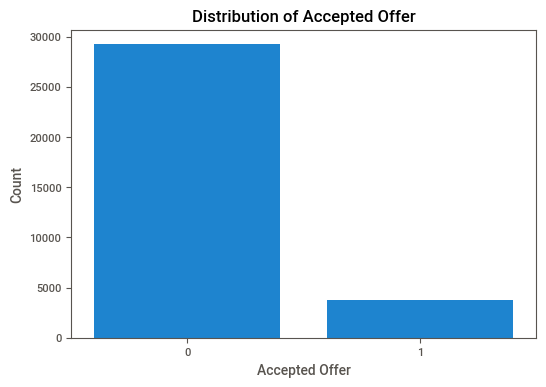

Overall acceptance rate: 11.27%


In [148]:
# Prints the distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(data=train, x=target)
plt.title("Distribution of Accepted Offer")
plt.xlabel("Accepted Offer")
plt.ylabel("Count")
plt.show()
acceptance_rate = train[target].mean()
print(f"Overall acceptance rate: {acceptance_rate:.2%}")

In [149]:
# Missing Value Check


missing_train = pd.DataFrame({
    "missing_count": train.isnull().sum(),
    "missing_percentage": (train.isnull().mean() * 100).round(2)
})

missing_train = missing_train[missing_train["missing_count"] > 0]
missing_train.sort_values(by="missing_percentage", ascending=False)



,missing_count,missing_percentage


There are no missing values in the data.

In [150]:
# Checks for Numeric and Categorical Features

id_col = "id"

numeric_features = train.drop(columns=[target]).select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = train.select_dtypes(include=["object"]).columns.tolist()

if id_col in numeric_features:
    numeric_features.remove(id_col)

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Number of numeric features: 12
Number of categorical features: 9

Numeric features:
['customer_age', 'contact_time_minutes', 'contact_attempt_count', 'days_since_prior_contact', 'prior_contact_count', 'economic_activity_change', 'consumer_price_index', 'consumer_confidence_index', 'reference_interest_rate', 'employment_level_index', 'is_repeat_customer', 'recent_contact_flag']

Categorical features:
['occupation_type', 'relationship_status', 'education_background', 'has_credit_issue', 'mortgage_status', 'personal_loan_status', 'last_contact_month', 'day_of_week', 'prior_outcome_status']


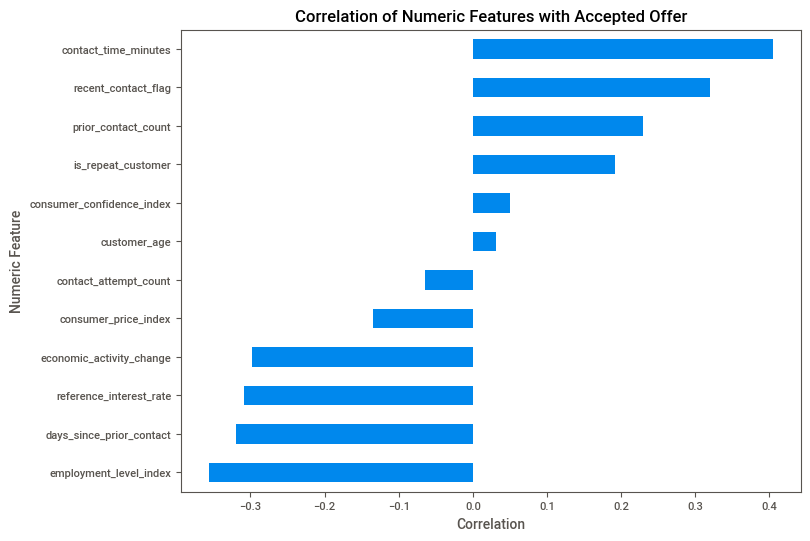

accepted_offer               1.000000
contact_time_minutes         0.404403
recent_contact_flag          0.319990
prior_contact_count          0.229570
is_repeat_customer           0.191969
consumer_confidence_index    0.050504
customer_age                 0.031586
contact_attempt_count       -0.065250
consumer_price_index        -0.134264
economic_activity_change    -0.298351
reference_interest_rate     -0.308602
days_since_prior_contact    -0.320040
employment_level_index      -0.355823
Name: accepted_offer, dtype: float64


In [151]:
# Correlation of numeric features with the target

numeric_corr = train[numeric_features + [target]].corr()[target].sort_values(ascending=False)
numeric_corr

plt.figure(figsize=(8, 6))
numeric_corr.drop(target).sort_values().plot(kind="barh")
plt.title("Correlation of Numeric Features with Accepted Offer")
plt.xlabel("Correlation")
plt.ylabel("Numeric Feature")
plt.show()

print(numeric_corr)

The variables that seem to have the highest correlation with accepted_offer are contact_time_minutes, recent_contact_flag, and _prior_contact_count, which suggests customers who have recent contact history are more likely to be accepted.

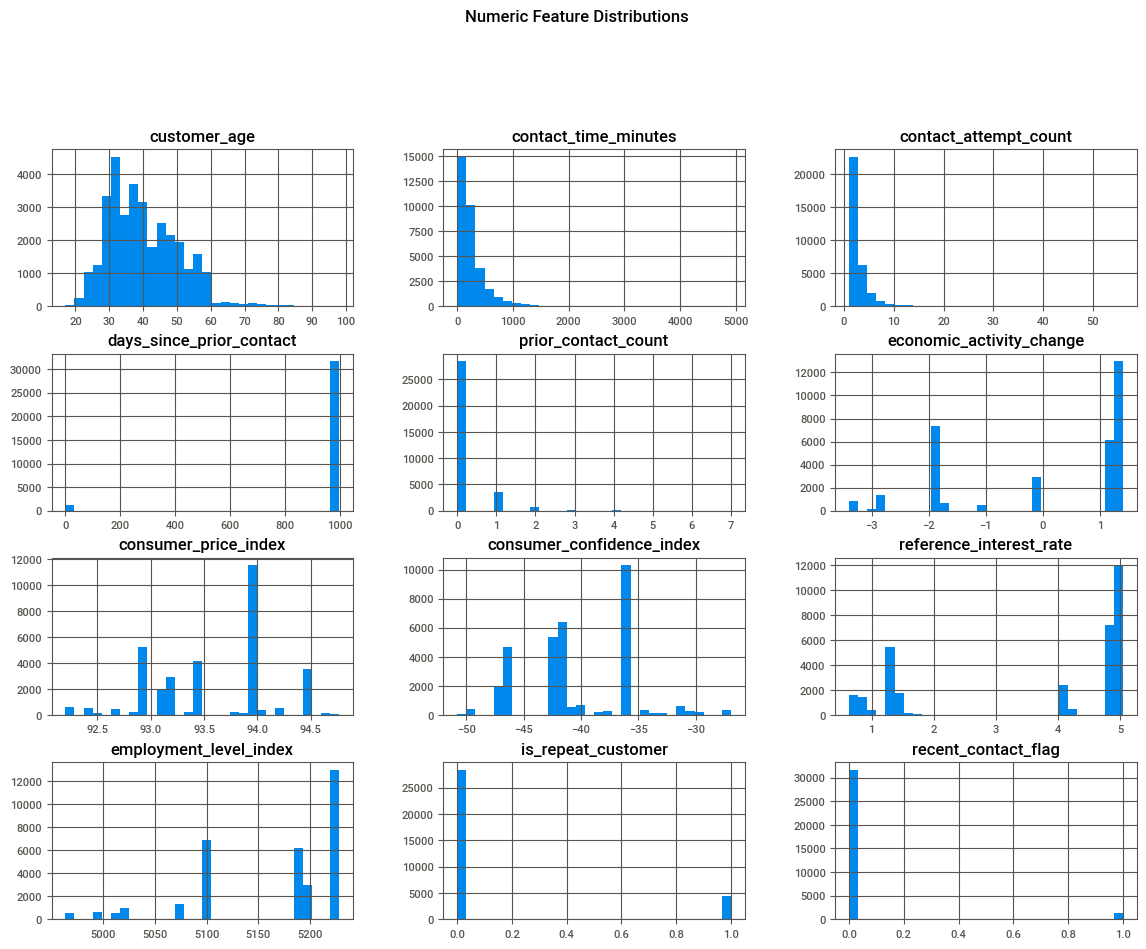

In [152]:
# Quick distribution plots for numeric features

train[numeric_features].hist(figsize=(14, 10), bins=30)
plt.suptitle("Numeric Feature Distributions", y=1.02)
plt.show()

In [153]:
# Review categorical feature cardinality

if len(categorical_features) > 0:
    categorical_summary = pd.DataFrame({
        "unique_values": train[categorical_features].nunique(),
        "missing_count": train[categorical_features].isnull().sum()
    }).sort_values(by="unique_values", ascending=False)

    display(categorical_summary)
else:
    print("No categorical features found.")

,unique_values,missing_count
occupation_type,12,0
last_contact_month,10,0
education_background,8,0
day_of_week,5,0
relationship_status,4,0
mortgage_status,3,0
has_credit_issue,3,0
personal_loan_status,3,0
prior_outcome_status,3,0


In [154]:
# Acceptance rate by category for categorical variables
# This helps identify categorical predictors that may be useful.

for col in categorical_features:
    category_summary = (
        train.groupby(col)[target]
        .agg(["count", "mean"])
        .sort_values(by="mean", ascending=False)
    )

    print("=" * 60)
    print(f"Acceptance Rate by {col}")
    display(category_summary.head(10))

Acceptance Rate by occupation_type


,count,mean
occupation_type,,
student,707,0.316832
retired,1376,0.257994
unemployed,792,0.138889
admin.,8336,0.130638
unknown,262,0.122137
self-employed,1133,0.109444
technician,5384,0.107912
management,2350,0.107234
housemaid,842,0.097387


Acceptance Rate by relationship_status


,count,mean
relationship_status,,
single,9319,0.140144
unknown,68,0.132353
divorced,3674,0.102885
married,19889,0.101664


Acceptance Rate by education_background


...

,count,mean
last_contact_month,,
mar,436,0.513761
dec,145,0.475862
sep,466,0.457082
oct,572,0.431818
apr,2118,0.209160
aug,4946,0.103922
jun,4262,0.103238
nov,3282,0.101767
jul,5743,0.091590


Acceptance Rate by day_of_week


,count,mean
day_of_week,,
thu,6893,0.121573
wed,6497,0.116977
tue,6456,0.116326
fri,6293,0.108057
mon,6811,0.100719


Acceptance Rate by prior_outcome_status


,count,mean
prior_outcome_status,,
success,1120,0.636607
failure,3378,0.142392
nonexistent,28452,0.088605


The information above shows the acceptance rate by categorical variables. It seems that prior_outcome_status appears to be very important as it has the highest acceptance rate compared to other categorical variables. With last_month_contact, it can be seen that there is a lot of variation within the months, showing that timing might matter when it comes to acceptance.

# Data Preparation: Show the preprocessing steps used for modeling. + Baseline Modeling

In [155]:
# Define target and id column for later use in modeling
target = "accepted_offer"
id_col = "id"

# Separate features and target for modeling

X = train.drop(columns=[target])
y = train[target]

# Save test IDs for final submission later since we will drop the ID column from modeling features
test_ids = test[id_col]

# Remove ID column from modeling features since it does not carry predictive information
X = X.drop(columns=[id_col])
X_test = test.drop(columns=[id_col])

# Shape check to confirm we have the expected number of features and samples
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (32950, 21)
y shape: (32950,)
X_test shape: (8238, 21)


In [156]:
# Identify numeric and categorical columns after removing id

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numeric features: 12
['customer_age', 'contact_time_minutes', 'contact_attempt_count', 'days_since_prior_contact', 'prior_contact_count', 'economic_activity_change', 'consumer_price_index', 'consumer_confidence_index', 'reference_interest_rate', 'employment_level_index', 'is_repeat_customer', 'recent_contact_flag']

Categorical features: 9
['occupation_type', 'relationship_status', 'education_background', 'has_credit_issue', 'mortgage_status', 'personal_loan_status', 'last_contact_month', 'day_of_week', 'prior_outcome_status']


In [157]:
# Create a stratified train/validation split
# Stratification keeps the accepted_offer class balance similar in both sets.

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)

print("\nTraining target balance:")
print(y_train.value_counts(normalize=True).round(3))

print("\nValidation target balance:")
print(y_val.value_counts(normalize=True).round(3))

# Class imbalance ratio
class_counts = y.value_counts()

majority_class = class_counts.max()
minority_class = class_counts.min()

imbalance_ratio = majority_class / minority_class

print("Class counts:")
print(class_counts)

print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")



Training set shape: (26360, 21)
Validation set shape: (6590, 21)

Training target balance:
accepted_offer
0    0.887
1    0.113
Name: proportion, dtype: float64

Validation target balance:
accepted_offer
0    0.887
1    0.113
Name: proportion, dtype: float64
Class counts:
accepted_offer
0    29235
1     3715
Name: count, dtype: int64

Imbalance ratio: 7.87:1


In [158]:
# Preprocessing pipelines for numeric and categorical features
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Fit the preprocessor only on the training split
# Then transform both training and validation data using the same preprocessing steps

In [159]:
#libraries for modeling
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [160]:
# Calculate class imbalance ratio for XGBoost
scale_pos_weight = (y == 0).sum() / (y == 1).sum()

print("Scale pos weight:", scale_pos_weight)
# Logistic Regression
log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        random_state=321,
        max_iter=1000
    ))
])

# Naive Bayes
nb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GaussianNB())
])

# Random Forest
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        class_weight="balanced",
        random_state=321,
        n_jobs=-1
    ))
])

# Extra Trees
et_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", ExtraTreesClassifier(
        class_weight="balanced",
        random_state=321,
        n_jobs=-1
    ))
])

# XGBoost
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        random_state=321,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

# LightGBM
lgbm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        is_unbalance=True,
        random_state=321,
        n_jobs=-1,
        verbose=-1
    ))
])

# Dictionary to hold all models for easy iteration during training and evaluation   
models = {
    "Logistic Regression": log_model,
    "Naive Bayes": nb_model,
    "Random Forest": rf_model,
    "Extra Trees": et_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}

Scale pos weight: 7.8694481830417224


In [161]:
# Evaluate each model on the validation set from log to LightGBM and collect performance metrics for comparison

results = []

for model_name, model in models.items():
    print("=" * 60)
    print(model_name)
    
    # Fit model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_val, y_proba)
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    })
    
    print(classification_report(y_val, y_pred, zero_division=0))

    # Convert results to a DataFrame

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

results_df

Logistic Regression
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      5847
           1       0.43      0.90      0.58       743

    accuracy                           0.86      6590
   macro avg       0.71      0.87      0.75      6590
weighted avg       0.92      0.86      0.88      6590

Naive Bayes
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      5847
           1       0.35      0.61      0.44       743

    accuracy                           0.83      6590
   macro avg       0.65      0.73      0.67      6590
weighted avg       0.88      0.83      0.85      6590

Random Forest
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      5847
           1       0.65      0.38      0.48       743

    accuracy                           0.91      6590
   macro avg       0.79      0.68      0.71      6590
weighted avg       0.89     

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
4,XGBoost,0.886191,0.497189,0.833109,0.622736,0.941074
5,LightGBM,0.871775,0.465772,0.934051,0.621585,0.948601
0,Logistic Regression,0.856297,0.433594,0.896366,0.584467,0.936709
2,Random Forest,0.906829,0.647597,0.380888,0.479661,0.939577
1,Naive Bayes,0.826252,0.346799,0.612382,0.442822,0.833046
3,Extra Trees,0.900303,0.609137,0.323015,0.422164,0.914285


The metric that I intend to focus on is F1 due to the target variable imbalance, as its a balance between precsion and recall. The baseline models that performs the best in F1 score is XGboost and LightGBM.

# Feature Engineering or Feature Selection: Evaluate whether feature engineering or feature selection improved or simplified your model.


In [162]:
from sklearn.preprocessing import PolynomialFeatures

In [163]:
# Feature Engineering or Feature Selection

# Based off our inittial EDA, we can create some engineered features to potentially improve model performance. Fixes the 999 issue with days_since_prior_contact and creates some interaction features based on contact behavior.

#Use only the training data to calculate cutoffs to avoid data leakage
contact_time_median = X_train["contact_time_minutes"].median()

def add_engineered_features(df):
    df = df.copy()
    
    # 1. Prior contact feature
    # 999 likely means the customer was not previously contacted
    df["was_previously_contacted"] = np.where(
        df["days_since_prior_contact"] == 999, 0, 1
    )
    
    # Cleaned version of days_since_prior_contact
    # This prevents 999 from being treated as a normal number of days
    df["days_since_prior_contact_clean"] = np.where(
        df["days_since_prior_contact"] == 999,
        0,
        df["days_since_prior_contact"]
    )
    
    # 2. Contact behavior features
    df["log_contact_time"] = np.log1p(df["contact_time_minutes"])
    df["log_contact_attempts"] = np.log1p(df["contact_attempt_count"])
    
    df["total_contact_count"] = (
        df["contact_attempt_count"] + df["prior_contact_count"]
    )
    
    df["long_contact_flag"] = np.where(
        df["contact_time_minutes"] > contact_time_median,
        1,
        0
    )
    
    return df

In [164]:
# This applies the engineered feature function to the training, validation, and test sets. We will then use these new features in our modeling pipelines.
X_train_fe = add_engineered_features(X_train)
X_val_fe = add_engineered_features(X_val)
X_test_fe = add_engineered_features(X_test)

In [165]:
# Select a small group of numeric variables for polynomial expansion. Used contact related variable since the EDA showed strong correlation to accepted_offer and we want to keep the number of added features manageable.

poly_input_features = [
    "contact_time_minutes",
    "contact_attempt_count",
    "prior_contact_count",
    "days_since_prior_contact_clean",
    "total_contact_count",
    "log_contact_time"
]


poly = PolynomialFeatures(
    degree=2,
    interaction_only=False,
    include_bias=False
)

# Fit only on training data to avoid leakage
poly.fit(X_train_fe[poly_input_features])

poly_feature_names = poly.get_feature_names_out(poly_input_features)

X_train_poly = pd.DataFrame(
    poly.transform(X_train_fe[poly_input_features]),
    columns=poly_feature_names,
    index=X_train_fe.index
)

X_val_poly = pd.DataFrame(
    poly.transform(X_val_fe[poly_input_features]),
    columns=poly_feature_names,
    index=X_val_fe.index
)

X_test_poly = pd.DataFrame(
    poly.transform(X_test_fe[poly_input_features]),
    columns=poly_feature_names,
    index=X_test_fe.index
)

In [166]:
# removes the original input features from the polynomial feature sets to avoid duplication since the original features are already included in the engineered feature sets we created earlier. This way we only keep the new polynomial features for modeling.
new_poly_cols = [
    col for col in poly_feature_names
    if col not in poly_input_features
]

X_train_poly = X_train_poly[new_poly_cols]
X_val_poly = X_val_poly[new_poly_cols]
X_test_poly = X_test_poly[new_poly_cols]

print("Number of new polynomial features added:", len(new_poly_cols))
print("New polynomial features:")
print(new_poly_cols)

Number of new polynomial features added: 21
New polynomial features:
['contact_time_minutes^2', 'contact_time_minutes contact_attempt_count', 'contact_time_minutes prior_contact_count', 'contact_time_minutes days_since_prior_contact_clean', 'contact_time_minutes total_contact_count', 'contact_time_minutes log_contact_time', 'contact_attempt_count^2', 'contact_attempt_count prior_contact_count', 'contact_attempt_count days_since_prior_contact_clean', 'contact_attempt_count total_contact_count', 'contact_attempt_count log_contact_time', 'prior_contact_count^2', 'prior_contact_count days_since_prior_contact_clean', 'prior_contact_count total_contact_count', 'prior_contact_count log_contact_time', 'days_since_prior_contact_clean^2', 'days_since_prior_contact_clean total_contact_count', 'days_since_prior_contact_clean log_contact_time', 'total_contact_count^2', 'total_contact_count log_contact_time', 'log_contact_time^2']


In [167]:
# Combine engineered features with polynomial features

X_train_fe_poly = pd.concat([X_train_fe, X_train_poly], axis=1)
X_val_fe_poly = pd.concat([X_val_fe, X_val_poly], axis=1)
X_test_fe_poly = pd.concat([X_test_fe, X_test_poly], axis=1)

print("Original feature engineered train shape:", X_train_fe.shape)
print("Mixed feature train shape:", X_train_fe_poly.shape)

print("\nOriginal feature engineered validation shape:", X_val_fe.shape)
print("Mixed feature validation shape:", X_val_fe_poly.shape)

print("\nOriginal feature engineered test shape:", X_test_fe.shape)
print("Mixed feature test shape:", X_test_fe_poly.shape)

Original feature engineered train shape: (26360, 27)
Mixed feature train shape: (26360, 48)

Original feature engineered validation shape: (6590, 27)
Mixed feature validation shape: (6590, 48)

Original feature engineered test shape: (8238, 27)
Mixed feature test shape: (8238, 48)


In [168]:
X_train_model = X_train_fe_poly.copy()
X_val_model = X_val_fe_poly.copy()
X_test_model = X_test_fe_poly.copy()

print("X_train_model shape:", X_train_model.shape)
print("X_val_model shape:", X_val_model.shape)
print("X_test_model shape:", X_test_model.shape)

numeric_features_model = X_train_model.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features_model = X_train_model.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric features:", len(numeric_features_model))
print("Categorical features:", len(categorical_features_model))

# Check if any selected columns are missing
missing_cols = [
    col for col in numeric_features_model + categorical_features_model
    if col not in X_train_model.columns
]

print("Missing selected columns:", missing_cols)

#Updated preprocessing pipelines to include the new engineered features. We will use these updated pipelines in our modeling to ensure all features are properly preprocessed before training the models.
numeric_transformer_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_model = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_model, numeric_features_model),
        ("cat", categorical_transformer_model, categorical_features_model)
    ]
)

X_train_model shape: (26360, 48)
X_val_model shape: (6590, 48)
X_test_model shape: (8238, 48)
Numeric features: 39
Categorical features: 9
Missing selected columns: []


# Modeling and Evaluation: Build and evaluate at least two models that differ in a meaningful way. Models should be tuned beyond default values. Use an appropriate validation strategy and evaluation metric.

In [179]:
# Pipelines for modeling with the new engineered features. We will use the same models as before but now with the enhanced feature set to see if we can improve performance.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("Scale pos weight:", scale_pos_weight)

log_model_mixed = Pipeline([
    ("preprocessor", preprocessor_model),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        random_state=321,
        max_iter=1000
    ))
])

nb_model_mixed = Pipeline([
    ("preprocessor", preprocessor_model),
    ("classifier", GaussianNB())
])

rf_model_mixed = Pipeline([
    ("preprocessor", preprocessor_model),
    ("classifier", RandomForestClassifier(
        class_weight="balanced",
        random_state=321,
        n_jobs=-1
    ))
])

et_model_mixed = Pipeline([
    ("preprocessor", preprocessor_model),
    ("classifier", ExtraTreesClassifier(
        class_weight="balanced",
        random_state=321,
        n_jobs=-1
    ))
])

xgb_model_mixed = Pipeline([
    ("preprocessor", preprocessor_model),
    ("classifier", XGBClassifier(
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        random_state=321,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

lgbm_model_mixed = Pipeline([
    ("preprocessor", preprocessor_model),
    ("classifier", LGBMClassifier(
        is_unbalance=True,
        random_state=321,
        n_jobs=-1,
        verbose=-1
    ))
])


Scale pos weight: 7.8694481830417224


In [180]:
# ============================================================
# Evaluate Mixed Feature Models One at a Time
# Engineered + Polynomial Feature Set
# ============================================================

def evaluate_model(model, model_name, X_train_data, X_val_data, y_train, y_val, feature_set_name):
    print("=" * 70)
    print(f"Training {model_name}...")
    
    model.fit(X_train_data, y_train)
    
    y_pred = model.predict(X_val_data)
    y_proba = model.predict_proba(X_val_data)[:, 1]
    
    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred, zero_division=0),
        "Recall": recall_score(y_val, y_pred, zero_division=0),
        "F1 Score": f1_score(y_val, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_val, y_proba),
        "Feature_Set": feature_set_name
    }
    
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred, zero_division=0))
    
    return result, y_pred, y_proba


# Store all mixed model results here
mixed_results = []
mixed_predictions = {}

# Logistic Regression Mixed
log_result, log_pred, log_proba = evaluate_model(
    model=log_model_mixed,
    model_name="Logistic Regression Mixed",
    X_train_data=X_train_model,
    X_val_data=X_val_model,
    y_train=y_train,
    y_val=y_val,
    feature_set_name="Engineered + Polynomial"
)

mixed_results.append(log_result)
mixed_predictions["Logistic Regression Mixed"] = {
    "y_pred": log_pred,
    "y_proba": log_proba
}


# Naive Bayes Mixed
nb_result, nb_pred, nb_proba = evaluate_model(
    model=nb_model_mixed,
    model_name="Naive Bayes Mixed",
    X_train_data=X_train_model,
    X_val_data=X_val_model,
    y_train=y_train,
    y_val=y_val,
    feature_set_name="Engineered + Polynomial"
)

mixed_results.append(nb_result)
mixed_predictions["Naive Bayes Mixed"] = {
    "y_pred": nb_pred,
    "y_proba": nb_proba
}


# Random Forest Mixed
rf_result, rf_pred, rf_proba = evaluate_model(
    model=rf_model_mixed,
    model_name="Random Forest Mixed",
    X_train_data=X_train_model,
    X_val_data=X_val_model,
    y_train=y_train,
    y_val=y_val,
    feature_set_name="Engineered + Polynomial"
)

mixed_results.append(rf_result)
mixed_predictions["Random Forest Mixed"] = {
    "y_pred": rf_pred,
    "y_proba": rf_proba
}


# Extra Trees Mixed
et_result, et_pred, et_proba = evaluate_model(
    model=et_model_mixed,
    model_name="Extra Trees Mixed",
    X_train_data=X_train_model,
    X_val_data=X_val_model,
    y_train=y_train,
    y_val=y_val,
    feature_set_name="Engineered + Polynomial"
)

mixed_results.append(et_result)
mixed_predictions["Extra Trees Mixed"] = {
    "y_pred": et_pred,
    "y_proba": et_proba
}


# XGBoost Mixed
xgb_result, xgb_pred, xgb_proba = evaluate_model(
    model=xgb_model_mixed,
    model_name="XGBoost Mixed",
    X_train_data=X_train_model,
    X_val_data=X_val_model,
    y_train=y_train,
    y_val=y_val,
    feature_set_name="Engineered + Polynomial"
)

mixed_results.append(xgb_result)
mixed_predictions["XGBoost Mixed"] = {
    "y_pred": xgb_pred,
    "y_proba": xgb_proba
}


# LightGBM Mixed
lgbm_result, lgbm_pred, lgbm_proba = evaluate_model(
    model=lgbm_model_mixed,
    model_name="LightGBM Mixed",
    X_train_data=X_train_model,
    X_val_data=X_val_model,
    y_train=y_train,
    y_val=y_val,
    feature_set_name="Engineered + Polynomial"
)

mixed_results.append(lgbm_result)
mixed_predictions["LightGBM Mixed"] = {
    "y_pred": lgbm_pred,
    "y_proba": lgbm_proba
}


# Final mixed model comparison table
results_mixed_df = pd.DataFrame(mixed_results)
results_mixed_df = results_mixed_df.sort_values(by="F1 Score", ascending=False)

results_mixed_df

Training Logistic Regression Mixed...

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.85      0.91      5847
           1       0.43      0.91      0.59       743

    accuracy                           0.86      6590
   macro avg       0.71      0.88      0.75      6590
weighted avg       0.92      0.86      0.88      6590

Training Naive Bayes Mixed...

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      5847
           1       0.47      0.56      0.51       743

    accuracy                           0.88      6590
   macro avg       0.71      0.74      0.72      6590
weighted avg       0.89      0.88      0.88      6590

Training Random Forest Mixed...

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      5847
           1       0.62      0.47      0.54       743

    accura

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Feature_Set
4,XGBoost Mixed,0.884370,0.492561,0.846568,0.622772,0.941825,Engineered + Polynomial
5,LightGBM Mixed,0.870258,0.461801,0.911171,0.612947,0.947941,Engineered + Polynomial
0,Logistic Regression Mixed,0.856146,0.433999,0.907133,0.587108,0.937529,Engineered + Polynomial
2,Random Forest Mixed,0.908042,0.621239,0.472409,0.536697,0.941963,Engineered + Polynomial
3,Extra Trees Mixed,0.901973,0.582624,0.460296,0.514286,0.936200,Engineered + Polynomial
1,Naive Bayes Mixed,0.878907,0.469136,0.562584,0.511628,0.898793,Engineered + Polynomial


In [181]:
#Comapres models with one another
comparison_df = pd.concat(
    [
        results_df.assign(Feature_Set="Original Features"),
        results_fe_df.assign(Feature_Set="Feature Engineered"),
        results_mixed_df.assign(Feature_Set="Engineered + Polynomial")
    ],
    ignore_index=True
)

comparison_df = comparison_df.sort_values(by="F1 Score", ascending=False)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Feature_Set
6,XGBoost FE,0.886950,0.499188,0.827725,0.622785,0.939460,Feature Engineered
12,XGBoost Mixed,0.884370,0.492561,0.846568,0.622772,0.941825,Engineered + Polynomial
0,XGBoost,0.886191,0.497189,0.833109,0.622736,0.941074,Original Features
1,LightGBM,0.871775,0.465772,0.934051,0.621585,0.948601,Original Features
7,LightGBM FE,0.872079,0.465753,0.915209,0.617340,0.947627,Feature Engineered
13,LightGBM Mixed,0.870258,0.461801,0.911171,0.612947,0.947941,Engineered + Polynomial
8,Logistic Regression FE,0.858877,0.439404,0.912517,0.593176,0.937856,Feature Engineered
14,Logistic Regression Mixed,0.856146,0.433999,0.907133,0.587108,0.937529,Engineered + Polynomial
2,Logistic Regression,0.856297,0.433594,0.896366,0.584467,0.936709,Original Features
9,Random Forest FE,0.911229,0.641577,0.481830,0.550346,0.941775,Feature Engineered


The best model so far is the XGBoost with manual feature engineering with an F1 scoer of 0.622785. THis was only slightly better between the mix of manual feature engineering and polynomialfeatures, which had an F1 score of 0.622772. However, regardless the top models were both XGboost and LighGBM. THis suggests that I should focus on these models for the final modeling. 

In [183]:
# Feature Selection Using Both XGBoost and LightGBM


X_train_select = X_train_fe.copy()
X_val_select = X_val_fe.copy()
X_test_select = X_test_fe.copy()

numeric_features_select = X_train_select.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features_select = X_train_select.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric features:", len(numeric_features_select))
print("Categorical features:", len(categorical_features_select))

# Build preprocessor for feature selection models
numeric_transformer_select = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_select = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_select = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_select, numeric_features_select),
        ("cat", categorical_transformer_select, categorical_features_select)
    ]
)


# 1. Feature importance from XGBoost

xgb_selector_model = Pipeline([
    ("preprocessor", preprocessor_select),
    ("classifier", XGBClassifier(
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        random_state=321,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

xgb_selector_model.fit(X_train_select, y_train)

# 2. Feature importance from LightGBM

lgbm_selector_model = Pipeline([
    ("preprocessor", preprocessor_select),
    ("classifier", LGBMClassifier(
        is_unbalance=True,
        random_state=321,
        n_jobs=-1,
        verbose=-1
    ))
])

lgbm_selector_model.fit(X_train_select, y_train)

# 3. Extract feature names after preprocessing to align with importance scores

fitted_preprocessor = xgb_selector_model.named_steps["preprocessor"]

numeric_names = numeric_features_select

categorical_names = fitted_preprocessor.named_transformers_["cat"] \
    .named_steps["onehot"] \
    .get_feature_names_out(categorical_features_select)

all_feature_names = np.concatenate([numeric_names, categorical_names])


# Feature tables showing the importance scores from both XGBoost and LightGBM for the features used in the selection process.

xgb_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "XGB_Importance": xgb_selector_model.named_steps["classifier"].feature_importances_
}).sort_values(by="XGB_Importance", ascending=False)

lgbm_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "LGBM_Importance": lgbm_selector_model.named_steps["classifier"].feature_importances_
}).sort_values(by="LGBM_Importance", ascending=False)

display(xgb_importance_df.head(20))
display(lgbm_importance_df.head(20))

Numeric features: 18
Categorical features: 9


,Feature,XGB_Importance
9,employment_level_index,0.373625
7,consumer_confidence_index,0.058328
1,contact_time_minutes,0.051696
5,economic_activity_change,0.049897
59,last_contact_month_oct,0.047302
57,last_contact_month_may,0.027635
68,prior_outcome_status_success,0.018115
8,reference_interest_rate,0.017695
3,days_since_prior_contact,0.016500
6,consumer_price_index,0.014303


,Feature,LGBM_Importance
1,contact_time_minutes,497
8,reference_interest_rate,455
0,customer_age,346
14,log_contact_time,204
2,contact_attempt_count,116
6,consumer_price_index,108
16,total_contact_count,88
5,economic_activity_change,79
7,consumer_confidence_index,74
13,days_since_prior_contact_clean,60


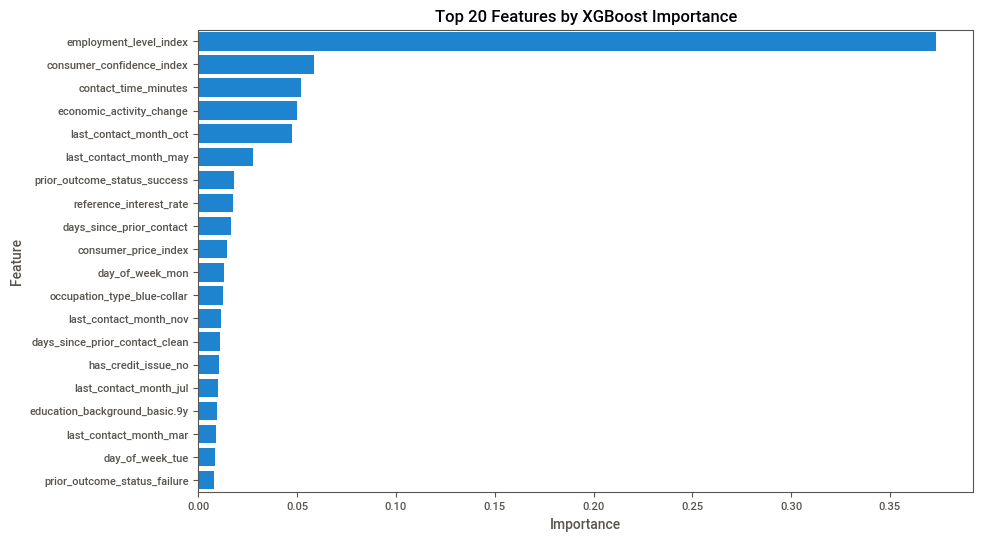

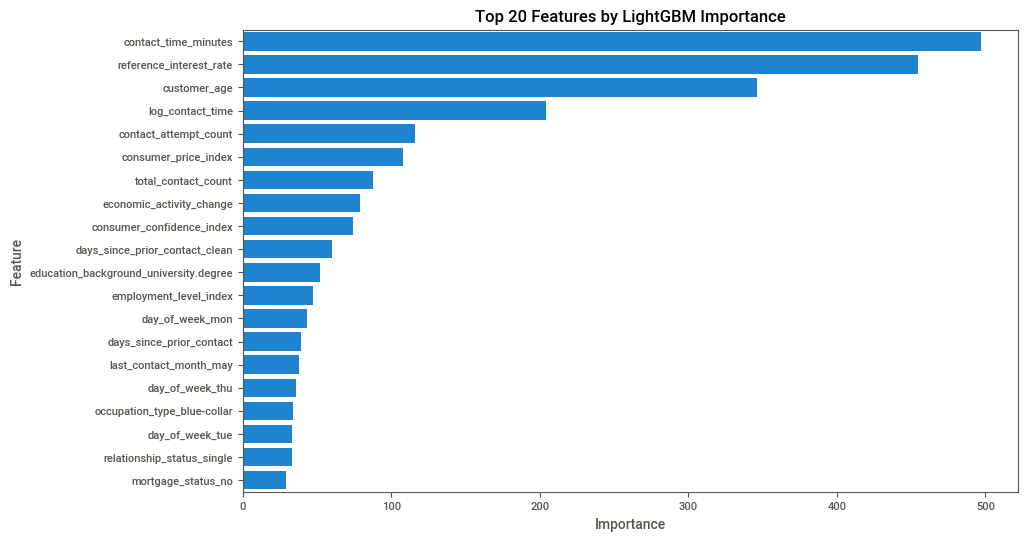

In [184]:
#PLots to visualize the top 20 most important features according to both XGBoost and LightGBM. This helps us understand which features are driving the predictions in each model and can inform our feature selection decisions for the final model we choose to deploy.
plt.figure(figsize=(10, 6))
sns.barplot(
    data=xgb_importance_df.head(20),
    x="XGB_Importance",
    y="Feature"
)
plt.title("Top 20 Features by XGBoost Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=lgbm_importance_df.head(20),
    x="LGBM_Importance",
    y="Feature"
)
plt.title("Top 20 Features by LightGBM Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [186]:

# Select top original numeric features from each model
top_xgb_numeric = xgb_importance_df[
    xgb_importance_df["Feature"].isin(numeric_features_select)
]["Feature"].head(15).tolist()

top_lgbm_numeric = lgbm_importance_df[
    lgbm_importance_df["Feature"].isin(numeric_features_select)
]["Feature"].head(15).tolist()

# Combine selected numeric features from both models
top_numeric_features_combined = sorted(
    list(set(top_xgb_numeric + top_lgbm_numeric))
)

# Keep all categorical features because they represent customer groups
selected_features = top_numeric_features_combined + categorical_features_select

print("Top numeric features from XGBoost:")
print(top_xgb_numeric)

print("\nTop numeric features from LightGBM:")
print(top_lgbm_numeric)

print("\nCombined selected numeric features:")
print(top_numeric_features_combined)

print("\nCategorical features kept:")
print(categorical_features_select)

print("\nTotal selected features:", len(selected_features))

# Create reduced datasets
X_train_reduced = X_train_fe[selected_features].copy()
X_val_reduced = X_val_fe[selected_features].copy()
X_test_reduced = X_test_fe[selected_features].copy()

print("\nFull feature-engineered shape:", X_train_fe.shape)
print("Reduced feature-engineered shape:", X_train_reduced.shape)

Top numeric features from XGBoost:
['employment_level_index', 'consumer_confidence_index', 'contact_time_minutes', 'economic_activity_change', 'reference_interest_rate', 'days_since_prior_contact', 'consumer_price_index', 'days_since_prior_contact_clean', 'customer_age', 'contact_attempt_count', 'total_contact_count', 'prior_contact_count', 'long_contact_flag', 'was_previously_contacted', 'log_contact_time']

Top numeric features from LightGBM:
['contact_time_minutes', 'reference_interest_rate', 'customer_age', 'log_contact_time', 'contact_attempt_count', 'consumer_price_index', 'total_contact_count', 'economic_activity_change', 'consumer_confidence_index', 'days_since_prior_contact_clean', 'employment_level_index', 'days_since_prior_contact', 'prior_contact_count', 'recent_contact_flag', 'long_contact_flag']

Combined selected numeric features:
['consumer_confidence_index', 'consumer_price_index', 'contact_attempt_count', 'contact_time_minutes', 'customer_age', 'days_since_prior_conta

In [ ]:
# Evaluate Reduced Feature-Engineered Dataset

# Re-identify numeric and categorical features for reduced dataset
numeric_features_reduced = X_train_reduced.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features_reduced = X_train_reduced.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# Build preprocessor for reduced feature set
numeric_transformer_reduced = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_reduced = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_reduced = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_reduced, numeric_features_reduced),
        ("cat", categorical_transformer_reduced, categorical_features_reduced)
    ]
)

# Build models for reduced feature set using the same algorithms as before to see how performance changes when we focus on the most important features according to XGBoost and LightGBM.
xgb_reduced_model = Pipeline([
    ("preprocessor", preprocessor_reduced),
    ("classifier", XGBClassifier(
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        random_state=321,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

lgbm_reduced_model = Pipeline([
    ("preprocessor", preprocessor_reduced),
    ("classifier", LGBMClassifier(
        is_unbalance=True,
        random_state=321,
        n_jobs=-1,
        verbose=-1
    ))
])

# Evaluate models
models_reduced = {
    "XGBoost Reduced FE": xgb_reduced_model,
    "LightGBM Reduced FE": lgbm_reduced_model
}

results_reduced = []

for model_name, model in models_reduced.items():
    print("=" * 60)
    print(f"Training {model_name}...")
    
    model.fit(X_train_reduced, y_train)
    
    y_pred = model.predict(X_val_reduced)
    y_proba = model.predict_proba(X_val_reduced)[:, 1]
    
    results_reduced.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred, zero_division=0),
        "Recall": recall_score(y_val, y_pred, zero_division=0),
        "F1 Score": f1_score(y_val, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_val, y_proba),
        "Feature_Set": "Reduced Feature Engineered"
    })

results_reduced_df = pd.DataFrame(results_reduced)
results_reduced_df = results_reduced_df.sort_values(by="F1 Score", ascending=False)

results_reduced_df

Training XGBoost Reduced FE...
Training LightGBM Reduced FE...


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Feature_Set
1,LightGBM Reduced FE,0.871775,0.465400,0.923284,0.618854,0.947672,Reduced Feature Engineered
0,XGBoost Reduced FE,0.882398,0.487558,0.843876,0.618038,0.940090,Reduced Feature Engineered


The performance of the reduced features using feature selection is worse then without reducing the amount of features. 

# Modeling and Evaluation: Build and evaluate at least two models that differ in a meaningful way. Models should be tuned beyond default values. Use an appropriate validation strategy and evaluation metric.


In [ ]:
# Modeling and Evaluation
# XGBoost and LightGBM on Full Feature-Engineered Dataset + Polynomial Features

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# Use the full feature-engineered dataset
X_train_model = X_train_fe_poly.copy()
X_val_model = X_val_fe_poly.copy()
X_test_model = X_test_fe_poly.copy()

# Re-identify numeric and categorical features from the exact dataset
numeric_features_model = X_train_model.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features_model = X_train_model.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric features:", len(numeric_features_model))
print("Categorical features:", len(categorical_features_model))

# Build preprocessor
numeric_transformer_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_model = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_model, numeric_features_model),
        ("cat", categorical_transformer_model, categorical_features_model)
    ]
)

# Class imbalance weight for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("Scale pos weight:", scale_pos_weight)

# XGBoost model
xgb_model_fe = Pipeline([
    ("preprocessor", preprocessor_model),
    ("classifier", XGBClassifier(
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        random_state=321,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

# LightGBM model
lgbm_model_fe = Pipeline([
    ("preprocessor", preprocessor_model),
    ("classifier", LGBMClassifier(
        is_unbalance=True,
        random_state=321,
        n_jobs=-1,
        verbose=-1
    ))
])

# Evaluate both models
models_fe_main = {
    "XGBoost FE": xgb_model_fe,
    "LightGBM FE": lgbm_model_fe
}

results_fe_main = []
model_predictions_fe_main = {}

for model_name, model in models_fe_main.items():
    print("=" * 60)
    print(f"Training {model_name}...")
    
    model.fit(X_train_model, y_train)
    
    y_pred = model.predict(X_val_model)
    y_proba = model.predict_proba(X_val_model)[:, 1]
    
    results_fe_main.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred, zero_division=0),
        "Recall": recall_score(y_val, y_pred, zero_division=0),
        "F1 Score": f1_score(y_val, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_val, y_proba),
        "Feature_Set": "Feature Engineered + Polynomial Features"
    })
    
    model_predictions_fe_main[model_name] = {
        "y_pred": y_pred,
        "y_proba": y_proba
    }
    
    print(classification_report(y_val, y_pred, zero_division=0))

results_fe_main_df = pd.DataFrame(results_fe_main)
results_fe_main_df = results_fe_main_df.sort_values(by="F1 Score", ascending=False)

results_fe_main_df

Numeric features: 39
Categorical features: 9
Scale pos weight: 7.8694481830417224
Training XGBoost FE...
              precision    recall  f1-score   support

           0       0.98      0.89      0.93      5847
           1       0.49      0.85      0.62       743

    accuracy                           0.88      6590
   macro avg       0.74      0.87      0.78      6590
weighted avg       0.92      0.88      0.90      6590

Training LightGBM FE...
              precision    recall  f1-score   support

           0       0.99      0.87      0.92      5847
           1       0.46      0.91      0.61       743

    accuracy                           0.87      6590
   macro avg       0.72      0.89      0.77      6590
weighted avg       0.93      0.87      0.89      6590



,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Feature_Set
0,XGBoost FE,0.884370,0.492561,0.846568,0.622772,0.941825,Feature Engineered + Polynomial Features + Pol...
1,LightGBM FE,0.870258,0.461801,0.911171,0.612947,0.947941,Feature Engineered + Polynomial Features + Pol...


In [192]:
# ============================================================
# Compare Full Feature Sets with Reduced Feature Set
# ============================================================

feature_selection_comparison_df = pd.concat(
    [
        comparison_df,
        results_reduced_df
    ],
    ignore_index=True
)

feature_selection_comparison_df = feature_selection_comparison_df.sort_values(
    by="F1 Score",
    ascending=False
)

feature_selection_comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Feature_Set
0,XGBoost FE,0.886950,0.499188,0.827725,0.622785,0.939460,Feature Engineered
1,XGBoost Mixed,0.884370,0.492561,0.846568,0.622772,0.941825,Engineered + Polynomial
2,XGBoost,0.886191,0.497189,0.833109,0.622736,0.941074,Original Features
3,LightGBM,0.871775,0.465772,0.934051,0.621585,0.948601,Original Features
18,LightGBM Reduced FE,0.871775,0.465400,0.923284,0.618854,0.947672,Reduced Feature Engineered
19,XGBoost Reduced FE,0.882398,0.487558,0.843876,0.618038,0.940090,Reduced Feature Engineered
4,LightGBM FE,0.872079,0.465753,0.915209,0.617340,0.947627,Feature Engineered
5,LightGBM Mixed,0.870258,0.461801,0.911171,0.612947,0.947941,Engineered + Polynomial
6,Logistic Regression FE,0.858877,0.439404,0.912517,0.593176,0.937856,Feature Engineered
7,Logistic Regression Mixed,0.856146,0.433999,0.907133,0.587108,0.937529,Engineered + Polynomial


The reduced feature-engineered dataset performed reasonably well, but it did not improve over the full feature-engineered dataset. XGBoost with the full feature-engineered dataset still had the highest F1 Score. This suggests that feature selection simplified the model, but some useful predictive information may have been removed. Because predictive performance is important for this project, I kept the full feature-engineered XGBoost model as the strongest candidate before tuning.

In [ ]:
## Model XGBoost with Full Feature-Engineered + Polynomial Features and LightGBM with Full Feature-Engineered + Polynomial Features performed the best. We will use these models to generate predictions on the test set for final submission.

In [197]:
# Hyperparameter Tuning for XGBoost and LightGBM using RandomizedSearchCV with StratifiedKFold cross-validation. We will tune the best performing models from our previous evaluations to see if we can further improve their performance before generating final predictions on the test set.
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Use the full feature-engineered dataset because it performed best before tuning
X_train_tune = X_train_fe.copy()
X_val_tune = X_val_fe.copy()
X_test_tune = X_test_fe.copy()

#numeric and categorical features
numeric_features_tune = X_train_tune.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features_tune = X_train_tune.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric features:", len(numeric_features_tune))
print("Categorical features:", len(categorical_features_tune))

# Build preprocessor for tuning
numeric_transformer_tune = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_tune = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_tune = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tune, numeric_features_tune),
        ("cat", categorical_transformer_tune, categorical_features_tune)
    ]
)

# Stratified cross-validation because the target is imbalanced
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=321
)


Numeric features: 18
Categorical features: 9


In [198]:
#XGBoost tuning
xgb_tune_model = Pipeline([
    ("preprocessor", preprocessor_tune),
    ("classifier", XGBClassifier(
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        random_state=321,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

xgb_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [3, 4, 5, 6],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0],
    "classifier__min_child_weight": [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_tune_model,
    param_distributions=xgb_param_grid,
    n_iter=12,
    scoring="f1",
    cv=cv,
    random_state=321,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train_tune, y_train)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print("\nBest XGBoost CV F1 Score:")
print(xgb_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best XGBoost parameters:
{'classifier__subsample': 0.8, 'classifier__n_estimators': 300, 'classifier__min_child_weight': 5, 'classifier__max_depth': 6, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 0.8}

Best XGBoost CV F1 Score:
0.6360512400278753


In [ ]:
#Evaluation of tuned xgboost

best_xgb = xgb_search.best_estimator_

xgb_tuned_pred = best_xgb.predict(X_val_tune)
xgb_tuned_proba = best_xgb.predict_proba(X_val_tune)[:, 1]

xgb_tuned_results = {
    "Model": "Tuned XGBoost FE",
    "Accuracy": accuracy_score(y_val, xgb_tuned_pred),
    "Precision": precision_score(y_val, xgb_tuned_pred, zero_division=0),
    "Recall": recall_score(y_val, xgb_tuned_pred, zero_division=0),
    "F1 Score": f1_score(y_val, xgb_tuned_pred, zero_division=0),
    "ROC AUC": roc_auc_score(y_val, xgb_tuned_proba),
    "Feature_Set": "Feature Engineered",
    "Validation": "5-Fold Stratified CV + Holdout Validation"
}

xgb_tuned_results


Tuned XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93      5847
           1       0.50      0.86      0.63       743

    accuracy                           0.89      6590
   macro avg       0.74      0.88      0.78      6590
weighted avg       0.93      0.89      0.90      6590



In [202]:
print("Tuned XGBoost Classification Report:")
print(classification_report(y_val, xgb_tuned_pred, zero_division=0))

Tuned XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93      5847
           1       0.50      0.86      0.63       743

    accuracy                           0.89      6590
   macro avg       0.74      0.88      0.78      6590
weighted avg       0.93      0.89      0.90      6590



In [208]:
#LightGBM tuning

lgbm_tune_model = Pipeline([
    ("preprocessor", preprocessor_tune),
    ("classifier", LGBMClassifier(
        is_unbalance=True,
        random_state=321,
        n_jobs=-1,
        verbose=-1
    ))
])

lgbm_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__num_leaves": [15, 31, 63],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__max_depth": [-1, 5, 10],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0],
    "classifier__min_child_samples": [10, 20, 40]
}

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_tune_model,
    param_distributions=lgbm_param_grid,
    n_iter=12,
    scoring="f1",
    cv=cv,
    random_state=321,
    n_jobs=-1,
    verbose=1
)

lgbm_search.fit(X_train_tune, y_train)

print("Best LightGBM parameters:")
print(lgbm_search.best_params_)

print("\nBest LightGBM CV F1 Score:")
print(lgbm_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best LightGBM parameters:
{'classifier__subsample': 0.8, 'classifier__num_leaves': 63, 'classifier__n_estimators': 200, 'classifier__min_child_samples': 40, 'classifier__max_depth': 10, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.8}

Best LightGBM CV F1 Score:
0.6368946390765444


In [209]:
# Evaluation of tuned LightGBM

best_lgbm = lgbm_search.best_estimator_

lgbm_tuned_pred = best_lgbm.predict(X_val_tune)
lgbm_tuned_proba = best_lgbm.predict_proba(X_val_tune)[:, 1]

lgbm_tuned_results = {
    "Model": "Tuned LightGBM FE",
    "Accuracy": accuracy_score(y_val, lgbm_tuned_pred),
    "Precision": precision_score(y_val, lgbm_tuned_pred, zero_division=0),
    "Recall": recall_score(y_val, lgbm_tuned_pred, zero_division=0),
    "F1 Score": f1_score(y_val, lgbm_tuned_pred, zero_division=0),
    "ROC AUC": roc_auc_score(y_val, lgbm_tuned_proba),
    "Feature_Set": "Feature Engineered",
    "Validation": "5-Fold Stratified CV + Holdout Validation"
}

lgbm_tuned_results

{'Model': 'Tuned LightGBM FE',
 'Accuracy': 0.8823975720789075,
 'Precision': 0.4885386819484241,
 'Recall': 0.917900403768506,
 'F1 Score': 0.6376811594202898,
 'ROC AUC': 0.9480968372272676,
 'Feature_Set': 'Feature Engineered',
 'Validation': '5-Fold Stratified CV + Holdout Validation'}

In [210]:
print("Tuned LightGBM Classification Report:")
print(classification_report(y_val, lgbm_tuned_pred, zero_division=0))

Tuned LightGBM Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      5847
           1       0.49      0.92      0.64       743

    accuracy                           0.88      6590
   macro avg       0.74      0.90      0.78      6590
weighted avg       0.93      0.88      0.90      6590



In [212]:
#comparison

tuned_results_df = pd.DataFrame([
    xgb_tuned_results,
    lgbm_tuned_results
])

final_modeling_comparison_df = pd.concat(
    [
        comparison_df,
        tuned_results_df
    ],
    ignore_index=True
)

final_modeling_comparison_df = final_modeling_comparison_df.sort_values(
    by="F1 Score",
    ascending=False
)

final_modeling_comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Feature_Set,Validation
19,Tuned LightGBM FE,0.882398,0.488539,0.917900,0.637681,0.948097,Feature Engineered,5-Fold Stratified CV + Holdout Validation
18,Tuned XGBoost FE,0.886798,0.498833,0.862719,0.632150,0.944143,Feature Engineered,5-Fold Stratified CV + Holdout Validation
0,XGBoost FE,0.886950,0.499188,0.827725,0.622785,0.939460,Feature Engineered,NaN
1,XGBoost Mixed,0.884370,0.492561,0.846568,0.622772,0.941825,Engineered + Polynomial,NaN
2,XGBoost,0.886191,0.497189,0.833109,0.622736,0.941074,Original Features,NaN
3,LightGBM,0.871775,0.465772,0.934051,0.621585,0.948601,Original Features,NaN
4,LightGBM FE,0.872079,0.465753,0.915209,0.617340,0.947627,Feature Engineered,NaN
5,LightGBM Mixed,0.870258,0.461801,0.911171,0.612947,0.947941,Engineered + Polynomial,NaN
6,Logistic Regression FE,0.858877,0.439404,0.912517,0.593176,0.937856,Feature Engineered,NaN
7,Logistic Regression Mixed,0.856146,0.433999,0.907133,0.587108,0.937529,Engineered + Polynomial,NaN


I tested original features, feature-engineered features, polynomial features, and reduced feature selection. Since the full feature-engineered dataset performed best by F1 Score before tuning, I used that feature set for hyperparameter tuning. Polynomial features did not clearly improve performance, so I did not tune that feature set further. The best models are the tuned lightGBM FE (f1 = 0.637681) and the tuned xgboost FE (f1 = 0.632150).

# Ensembling: Evaluate whether combining models improves performance. The models you combine should differ in a meaningful way.

In [213]:
# Get predicted probabilities from tuned models
xgb_val_proba = best_xgb.predict_proba(X_val_tune)[:, 1]
lgbm_val_proba = best_lgbm.predict_proba(X_val_tune)[:, 1]

# Simple average of predicted probabilities
ensemble_proba = (xgb_val_proba + lgbm_val_proba) / 2

# Convert probabilities to 0/1 predictions using default 0.50 threshold
ensemble_pred = (ensemble_proba >= 0.50).astype(int)

ensemble_results = {
    "Model": "Average Ensemble: Tuned XGBoost + Tuned LightGBM",
    "Accuracy": accuracy_score(y_val, ensemble_pred),
    "Precision": precision_score(y_val, ensemble_pred, zero_division=0),
    "Recall": recall_score(y_val, ensemble_pred, zero_division=0),
    "F1 Score": f1_score(y_val, ensemble_pred, zero_division=0),
    "ROC AUC": roc_auc_score(y_val, ensemble_proba),
    "Feature_Set": "Feature Engineered",
    "Validation": "Holdout Validation"
}

ensemble_results

{'Model': 'Average Ensemble: Tuned XGBoost + Tuned LightGBM',
 'Accuracy': 0.884825493171472,
 'Precision': 0.4940652818991098,
 'Recall': 0.8963660834454913,
 'F1 Score': 0.6370157819225251,
 'ROC AUC': 0.9468149337951776,
 'Feature_Set': 'Feature Engineered',
 'Validation': 'Holdout Validation'}

In [ ]:
# Ensemble Tuning
thresholds = np.arange(0.10, 0.91, 0.01)

threshold_results = []

for threshold in thresholds:
    preds = (ensemble_proba >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val, preds, zero_division=0),
        "Recall": recall_score(y_val, preds, zero_division=0),
        "F1 Score": f1_score(y_val, preds, zero_division=0)
    })

threshold_results_df = pd.DataFrame(threshold_results)

best_threshold_row = threshold_results_df.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]

best_threshold_row

Threshold    0.640000
Precision    0.532343
Recall       0.819650
F1 Score     0.645469
Name: 54, dtype: float64

In [216]:
# Evaluate ensemble using best threshold

best_ensemble_threshold = best_threshold_row["Threshold"]

ensemble_tuned_pred = (ensemble_proba >= best_ensemble_threshold).astype(int)

ensemble_tuned_results = {
    "Model": "Threshold-Tuned Ensemble: XGBoost + LightGBM",
    "Accuracy": accuracy_score(y_val, ensemble_tuned_pred),
    "Precision": precision_score(y_val, ensemble_tuned_pred, zero_division=0),
    "Recall": recall_score(y_val, ensemble_tuned_pred, zero_division=0),
    "F1 Score": f1_score(y_val, ensemble_tuned_pred, zero_division=0),
    "ROC AUC": roc_auc_score(y_val, ensemble_proba),
    "Feature_Set": "Feature Engineered",
    "Validation": f"Holdout Validation, Threshold={best_ensemble_threshold:.2f}"
}

ensemble_tuned_results

{'Model': 'Threshold-Tuned Ensemble: XGBoost + LightGBM',
 'Accuracy': 0.8984825493171472,
 'Precision': 0.5323426573426573,
 'Recall': 0.819650067294751,
 'F1 Score': 0.6454689984101749,
 'ROC AUC': 0.9468149337951776,
 'Feature_Set': 'Feature Engineered',
 'Validation': 'Holdout Validation, Threshold=0.64'}

In [ ]:
# Adding to comparison table
ensemble_results_df = pd.DataFrame([
    ensemble_results,
    ensemble_tuned_results
])

final_modeling_comparison_df = pd.concat(
    [
        final_modeling_comparison_df,
        ensemble_results_df
    ],
    ignore_index=True
)

final_modeling_comparison_df = final_modeling_comparison_df.sort_values(
    by="F1 Score",
    ascending=False
)

final_modeling_comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Feature_Set,Validation
21,Threshold-Tuned Ensemble: XGBoost + LightGBM,0.898483,0.532343,0.819650,0.645469,0.946815,Feature Engineered,"Holdout Validation, Threshold=0.64"
0,Tuned LightGBM FE,0.882398,0.488539,0.917900,0.637681,0.948097,Feature Engineered,5-Fold Stratified CV + Holdout Validation
20,Average Ensemble: Tuned XGBoost + Tuned LightGBM,0.884825,0.494065,0.896366,0.637016,0.946815,Feature Engineered,Holdout Validation
1,Tuned XGBoost FE,0.886798,0.498833,0.862719,0.632150,0.944143,Feature Engineered,5-Fold Stratified CV + Holdout Validation
2,XGBoost FE,0.886950,0.499188,0.827725,0.622785,0.939460,Feature Engineered,NaN
3,XGBoost Mixed,0.884370,0.492561,0.846568,0.622772,0.941825,Engineered + Polynomial,NaN
4,XGBoost,0.886191,0.497189,0.833109,0.622736,0.941074,Original Features,NaN
5,LightGBM,0.871775,0.465772,0.934051,0.621585,0.948601,Original Features,NaN
6,LightGBM FE,0.872079,0.465753,0.915209,0.617340,0.947627,Feature Engineered,NaN
7,LightGBM Mixed,0.870258,0.461801,0.911171,0.612947,0.947941,Engineered + Polynomial,NaN


Ensembling the 2 models showed that the Threshold Tuned Ensemble XGBoost + LightGBM showed the best F1 Score with 0.645469. This was better than the Average Ensemble model which had a f1 score of 0.637016.

# Results Summary: Summarize the models you evaluated and identify your final model. Include model name, key preprocessing or features, validation method, evaluation metric, validation score, and a brief reason for your final choice. Present this in a clear, structured format.


In [218]:
results_summary_df = final_modeling_comparison_df.copy()

results_summary_df = results_summary_df[
    [
        "Model",
        "Feature_Set",
        "Validation",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
]

results_summary_df["Validation"] = results_summary_df["Validation"].fillna(
    "Holdout Validation"
)

# Round numeric columns for readability
numeric_cols = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]

results_summary_df[numeric_cols] = results_summary_df[numeric_cols].round(4)

# Sort by main metric
results_summary_df = results_summary_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_summary_df

,Model,Feature_Set,Validation,Accuracy,Precision,Recall,F1 Score,ROC AUC
21,Threshold-Tuned Ensemble: XGBoost + LightGBM,Feature Engineered,"Holdout Validation, Threshold=0.64",0.8985,0.5323,0.8197,0.6455,0.9468
0,Tuned LightGBM FE,Feature Engineered,5-Fold Stratified CV + Holdout Validation,0.8824,0.4885,0.9179,0.6377,0.9481
20,Average Ensemble: Tuned XGBoost + Tuned LightGBM,Feature Engineered,Holdout Validation,0.8848,0.4941,0.8964,0.6370,0.9468
1,Tuned XGBoost FE,Feature Engineered,5-Fold Stratified CV + Holdout Validation,0.8868,0.4988,0.8627,0.6321,0.9441
2,XGBoost FE,Feature Engineered,Holdout Validation,0.8869,0.4992,0.8277,0.6228,0.9395
3,XGBoost Mixed,Engineered + Polynomial,Holdout Validation,0.8844,0.4926,0.8466,0.6228,0.9418
4,XGBoost,Original Features,Holdout Validation,0.8862,0.4972,0.8331,0.6227,0.9411
5,LightGBM,Original Features,Holdout Validation,0.8718,0.4658,0.9341,0.6216,0.9486
6,LightGBM FE,Feature Engineered,Holdout Validation,0.8721,0.4658,0.9152,0.6173,0.9476
7,LightGBM Mixed,Engineered + Polynomial,Holdout Validation,0.8703,0.4618,0.9112,0.6129,0.9479


In [219]:
# Identify best model by F1 Score

best_model_row = results_summary_df.iloc[0]
best_model_row

Model          Threshold-Tuned Ensemble: XGBoost + LightGBM
Feature_Set                              Feature Engineered
Validation               Holdout Validation, Threshold=0.64
Accuracy                                             0.8985
Precision                                            0.5323
Recall                                               0.8197
F1 Score                                             0.6455
ROC AUC                                              0.9468
Name: 21, dtype: object

Overall, the best model was Threshold-Tuned Ensemble: XGBoost + LightGBM:

Feature_Set                              Feature Engineered
Validation               Holdout Validation, Threshold=0.64
Accuracy                                             0.8985
Precision                                            0.5323
Recall                                               0.8197
F1 Score                                             0.6455
ROC AUC                                              0.9468

Validation: 
5-Fold Stratified Cross Validation

Important Metrics:
F1 Score was used as the primary evaluation metric because the target variable was imbalanced and the goal was to identify customers who were likely to accept the offer. 
ROC AUC was also used as a secondary metric because it measures how well the model separates likely acceptors from non-acceptors across different thresholds.


This was due to the highest f1 score of 0.6455 amongst the other models, showing the ensemble of both XGBoost and LightGBM helped capture complementary patterns in the data. Additionally, having one of the strongest ROC AUC scores of 0.9468, also contributed to my decision on why it was the best model. The threshold-tuning also contributed to a better model since there was quite the imbalance with the target variable. 

# Final Model and Predictions: Train your final model and generate predictions for the test set. Do not use the test set for tuning.

In [220]:
# Final Predictions on Test Set using the best model (Tuned XGBoost FE)

target = "accepted_offer"
id_col = "id"

X_full = train.drop(columns=[target, id_col])
y_full = train[target]

test_ids = test[id_col]
X_test_final = test.drop(columns=[id_col])

print("Full training shape:", X_full.shape)
print("Test shape:", X_test_final.shape)

Full training shape: (32950, 21)
Test shape: (8238, 21)


In [ ]:
# Apply the same feature engineering used during modeling

contact_time_median = X_full["contact_time_minutes"].median()

X_full_fe = add_engineered_features(X_full)
X_test_final_fe = add_engineered_features(X_test_final)

print("Full feature-engineered training shape:", X_full_fe.shape)
print("Feature-engineered test shape:", X_test_final_fe.shape)

Full feature-engineered training shape: (32950, 27)
Feature-engineered test shape: (8238, 27)


In [ ]:
# Refit tuned models on the full training data

final_xgb = best_xgb
final_lgbm = best_lgbm

final_xgb.fit(X_full_fe, y_full)
final_lgbm.fit(X_full_fe, y_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [227]:
# Generate predicted probabilities on the test set

xgb_test_proba = final_xgb.predict_proba(X_test_final_fe)[:, 1]
lgbm_test_proba = final_lgbm.predict_proba(X_test_final_fe)[:, 1]

# Average the model probabilities for the final ensemble
final_ensemble_proba = (xgb_test_proba + lgbm_test_proba) / 2

# Apply the best validation threshold

final_threshold = 0.64

final_predictions = (final_ensemble_proba >= final_threshold).astype(int)


submission = pd.DataFrame({
    "id": test_ids,
    "prediction": final_predictions
})

submission.head()

# Save predictions as required

output_filename = "Le_Nicholas_predictions.csv"

submission.to_csv(output_filename, index=False)

print(f"Saved prediction file as: {output_filename}")
print("Submission shape:", submission.shape)

print("\nPrediction counts:")
print(submission["prediction"].value_counts())

Saved prediction file as: Le_Nicholas_predictions.csv
Submission shape: (8238, 2)

Prediction counts:
prediction
0    6834
1    1404
Name: count, dtype: int64
